# Streets of Coverage Validation: Iridium

A streets-of-coverage constellation places satellites in several orbital planes so that the footprints of the satellites in each plane overlap into a continuous "street" and the streets of adjacent planes overlap, providing continuous coverage of the Earth. TAT-C generates such constellations with `SOCConstellation`, from a reference circular orbit, the footprint (swath) diameter at a minimum elevation angle, and a packing distance between footprints. The [Iridium](https://www.iridium.com/) satellite communications constellation is the classic example: 66 satellites in six near-polar planes at 780 km altitude, which provide continuous global coverage above an 8.2 deg elevation angle. This notebook compares TAT-C's streets-of-coverage design and coverage analysis with Iridium, and asks:

1. **Design.** Does `SOCConstellation` reproduce Iridium's numbers of planes and satellites per plane for its altitude and minimum elevation angle?
2. **Coverage.** Does TAT-C's coverage analysis (`collect_multi_observations`, `aggregate_observations`) reproduce the continuous coverage of the operational constellation, and do generated constellations provide it?

## Reference Data

Two-line element (TLE) sets of the Iridium NEXT satellites are retrieved from [CelesTrak](https://celestrak.org/) (epochs of 3 and 4 October 2026) and cached in a local `data/orbits` directory. The operational satellites are those at the operational altitude (mean motion within 0.02 revolutions per day of the median); the others are spares or satellites being raised or lowered. The analysis period is 12 hours from 00:00 UTC on 4 October 2026.

In [1]:
import concurrent.futures
import math
from datetime import datetime, timedelta, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from skyfield.api import wgs84
from skyfield.framelib import itrs

from tatc.analysis import aggregate_observations, collect_multi_observations
from tatc.constants import EARTH_MEAN_RADIUS, timescale
from tatc.generation import generate_points_fibonacci_lattice
from tatc.schemas import CircularOrbit, GeneralPerturbationsOrbit, Instrument, Point, Satellite, SOCConstellation, WalkerConstellation
from tatc.schemas.space.walker import WalkerConfiguration
from tatc.utils import compute_field_of_regard

ORBIT_DIR = Path("data") / "orbits"
ORBIT_DIR.mkdir(parents=True, exist_ok=True)
START = datetime(2026, 10, 4, tzinfo=timezone.utc)
END = START + timedelta(hours=12)
path = ORBIT_DIR / "iridium-NEXT.tle"
if not path.exists():
    response = requests.get("https://celestrak.org/NORAD/elements/gp.php", params={"GROUP": "iridium-NEXT", "FORMAT": "tle"}, timeout=120)
    response.raise_for_status()
    path.write_text(response.text)
lines = [line.rstrip() for line in path.read_text().splitlines() if line.strip()]
tles = pd.DataFrame(
    [
        {
            "name": lines[i].strip(),
            "tle": lines[i + 1 : i + 3],
            "inclination": float(lines[i + 2][8:16]),
            "raan": float(lines[i + 2][17:25]),
            "mean_motion": float(lines[i + 2][52:63]),
        }
        for i in range(0, len(lines) - 2, 3)
    ]
)
operational = tles[(tles.mean_motion - tles.mean_motion.median()).abs() < 0.02].copy()
# planes: clusters of right ascension of ascending node
operational = operational.sort_values("raan")
operational["plane"] = (operational.raan.diff() > 5).cumsum()
planes = operational.groupby("plane").agg(raan=("raan", "mean"), satellites=("name", "size"), inclination=("inclination", "mean"))
spacing = np.diff(np.r_[planes.raan.to_numpy(), planes.raan.iloc[0] + 360])
planes["spacing to next plane (deg)"] = spacing
ALTITUDE = (398600.4418e9 / (2 * np.pi * operational.mean_motion.median() / 86400) ** 2) ** (1 / 3) - EARTH_MEAN_RADIUS
INCLINATION = operational.inclination.mean()
MIN_ELEVATION = 8.2
BLUE, ORANGE, AQUA, GRAY, INK, PURPLE = "#2a78d6", "#eb6834", "#1baf7a", "#8a8984", "#0b0b0b", "#8e5bd8"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.6})
print(f"{len(tles)} Iridium NEXT TLEs, {len(operational)} operational; mean altitude {ALTITUDE / 1e3:.0f} km, inclination {INCLINATION:.2f} deg")
planes.round(1)

80 Iridium NEXT TLEs, 67 operational; mean altitude 785 km, inclination 86.40 deg


,raan,satellites,inclination,spacing to next plane (deg)
plane,,,,
0,11.0,12,86.4,31.6
1,42.7,11,86.4,202.0
2,244.7,11,86.4,31.6
3,276.3,11,86.4,31.6
4,307.9,11,86.4,31.6
5,339.5,11,86.4,31.5


The operational satellites occupy six planes spanning about 180 deg of right ascension, 31.6 deg apart, with one plane holding a twelfth satellite (an active spare). The satellites in adjacent planes move in the same direction, except across the 22 deg "seam" between the first and last planes, where the ascending side of one plane faces the descending side of the other.

## Test 1: Design

The footprint of a satellite at 780 km altitude above an 8.2 deg minimum elevation angle has an Earth central angle (radius) of about 19.9 deg. Classical streets-of-coverage theory for polar orbits (Adams and Rider, 1987) gives the number of satellites per plane $S$ and planes $P$ for continuous single coverage: each plane's street has a half width $c$ with $\cos c = \cos \gamma / \cos(\pi / S)$, co-rotating planes are separated by $\gamma + c$, counter-rotating planes (at the seam) by $2c$, and the planes span 180 deg: $(P - 1)(\gamma + c) + 2c \geq 180$ deg. `SOCConstellation` is evaluated for the same orbit and footprint with packing distances from 0.8 to 1.

In [2]:
eta = math.degrees(math.asin(EARTH_MEAN_RADIUS / (EARTH_MEAN_RADIUS + ALTITUDE) * math.cos(math.radians(MIN_ELEVATION))))
gamma = 90 - MIN_ELEVATION - eta
swath_width = 2 * math.radians(gamma) * EARTH_MEAN_RADIUS
orbit = CircularOrbit(altitude=ALTITUDE, inclination=INCLINATION, epoch=START)


def polar_streets(gamma, satellites_per_plane):
    """Planes and spacings of a polar streets-of-coverage design (Adams and Rider, 1987)."""
    c = math.degrees(math.acos(math.cos(math.radians(gamma)) / math.cos(math.pi / satellites_per_plane)))
    planes = math.ceil((180 - 2 * c) / (gamma + c) + 1)
    return planes, gamma + c, 2 * c


rows1 = {"Iridium (operational)": {"satellites per plane": 11, "planes": len(planes), "satellites": 11 * len(planes), "plane spacing (deg)": float(np.median(spacing[spacing < 90])), "seam spacing (deg)": 180 - (len(planes) - 1) * float(np.median(spacing[spacing < 90])), "planes span (deg)": 180}}
for s in (10, 11, 12):
    p, co, seam = polar_streets(gamma, s)
    rows1[f"polar streets of coverage, {s} per plane"] = {"satellites per plane": s, "planes": p, "satellites": s * p, "plane spacing (deg)": co, "seam spacing (deg)": seam, "planes span (deg)": 180}
for packing in (1.0, 0.9, 0.8):
    walker = SOCConstellation(name="SOC", orbit=orbit, swath_width=swath_width, packing_distance=packing).generate_walker()
    rows1[f"SOCConstellation, packing distance {packing}"] = {
        "satellites per plane": walker.number_satellites // walker.number_planes,
        "planes": walker.number_planes,
        "satellites": walker.number_satellites,
        "plane spacing (deg)": walker.get_delta_raan_between_planes(),
        "seam spacing (deg)": np.nan,
        "planes span (deg)": 360 if walker.configuration == WalkerConfiguration.DELTA else 180,
    }
print(f"footprint radius {gamma:.2f} deg ({swath_width / 2e3:.0f} km), swath width {swath_width / 1e3:.0f} km")
pd.DataFrame(rows1).T.round(1)

footprint radius 20.01 deg (2225 km), swath width 4450 km


,satellites per plane,planes,satellites,plane spacing (deg),seam spacing (deg),planes span (deg)
Iridium (operational),11.0,6.0,66.0,31.6,21.9,180.0
"polar streets of coverage, 10 per plane",10.0,7.0,70.0,28.9,17.8,180.0
"polar streets of coverage, 11 per plane",11.0,6.0,66.0,31.7,23.4,180.0
"polar streets of coverage, 12 per plane",12.0,6.0,72.0,33.4,26.8,180.0
"SOCConstellation, packing distance 1.0",9.0,11.0,99.0,32.7,NaN,360.0
"SOCConstellation, packing distance 0.9",11.0,12.0,132.0,30.0,NaN,360.0
"SOCConstellation, packing distance 0.8",12.0,14.0,168.0,25.7,NaN,360.0


Classical streets-of-coverage theory reproduces Iridium's design: with 11 satellites per plane, six planes 31.7 deg apart (with a 23.4 deg seam) provide continuous coverage, matching Iridium's 31.6 deg spacing and 22 deg seam; ten satellites per plane would require seven planes and twelve would not reduce the number of planes.

`SOCConstellation` does not: with a packing distance of 1, it places 9 satellites in each of 11 planes (99 satellites), and with smaller packing distances, 132 or 168. It differs from the polar design in two ways. First, its in-plane spacing (twice the footprint radius times the packing distance) makes adjacent footprints in a plane touch at a packing distance of 1, leaving no overlap to form a continuous street (a hexagonal covering requires a packing distance of about 0.87). Second, it spreads its planes over 360 deg of right ascension (a Walker delta pattern), as suits inclined orbits; for near-polar orbits, the ascending and descending halves of planes 180 deg apart cover the same streets, so a polar design needs planes over only 180 deg (a Walker star pattern).

## Test 2: Coverage

The points of interest are those of a Fibonacci lattice with a typical spacing of 1,000 km. Each satellite carries an instrument whose field of regard corresponds to the 8.2 deg minimum elevation angle at 780 km altitude. For each point, `collect_multi_observations` collects the observations of every satellite over the 12-hour period, and `aggregate_observations` merges overlapping observations into periods of continuous coverage, separated by gaps (revisits). Four constellations are compared:

* **Iridium (operational)**: the 67 operational satellites, from their TLEs;
* **Walker star 66/6**: 66 satellites in six planes spaced 30 deg over 180 deg (TAT-C's `WalkerConstellation` with the star configuration), with adjacent planes phased by half the in-plane spacing, as Iridium's;
* **SOCConstellation**: TAT-C's streets-of-coverage design with a packing distance of 1;
* **Iridium, 10 per plane**: the operational planes with one fewer satellite per plane (the first ten of each), which theory predicts cannot provide continuous coverage.

For the operational constellation, the coverage is also computed independently by sampling the satellites' elevation angles from each point every 20 s.

In [3]:
lattice = generate_points_fibonacci_lattice(1000e3)
points = [Point(id=int(r.point_id), latitude=r.geometry.y, longitude=r.geometry.x) for r in lattice.itertuples()]
instrument = Instrument(name="antenna", field_of_regard=compute_field_of_regard(ALTITUDE, MIN_ELEVATION))
constellations = {
    "Iridium (operational)": [Satellite(name=r.name, orbit=GeneralPerturbationsOrbit.from_tle(r.tle), instruments=[instrument]) for r in operational.itertuples()],
    "Walker star 66/6": WalkerConstellation(name="star", orbit=orbit, instruments=[instrument], number_satellites=66, number_planes=6, relative_spacing=3, configuration=WalkerConfiguration.STAR).generate_members(),
    "SOCConstellation": SOCConstellation(name="SOC", orbit=orbit, instruments=[instrument], swath_width=swath_width, packing_distance=1.0).generate_members(),
    "Iridium, 10 per plane": [Satellite(name=r.name, orbit=GeneralPerturbationsOrbit.from_tle(r.tle), instruments=[instrument]) for r in operational.groupby("plane").head(10).itertuples()],
}
PERIOD = (END - START).total_seconds()


def coverage(satellites):
    """Coverage statistics of each point from TAT-C's aggregated observations."""
    def point_coverage(point):
        obs = collect_multi_observations(point, satellites, START, END)
        if obs.empty:
            return {"point_id": point.id, "latitude": point.latitude, "covered (%)": 0.0, "max gap (min)": PERIOD / 60}
        merged = aggregate_observations(obs)
        covered = merged.access.dt.total_seconds().sum()
        # gaps between periods, and before the first and after the last
        gaps = np.r_[(merged.start.iloc[0] - START).total_seconds(), merged.revisit.dt.total_seconds().dropna().to_numpy(), (END - merged.end.iloc[-1]).total_seconds()]
        return {"point_id": point.id, "latitude": point.latitude, "covered (%)": 100 * min(covered, PERIOD) / PERIOD, "max gap (min)": max(0.0, gaps.max()) / 60}

    with concurrent.futures.ThreadPoolExecutor(8) as pool:
        return pd.DataFrame(list(pool.map(point_coverage, points)))


results = {label: coverage(satellites) for label, satellites in constellations.items()}

# independent check: sampled elevation angles of the operational satellites
times = timescale.from_datetimes([START + timedelta(seconds=s) for s in range(0, int(PERIOD), 20)])
positions = np.stack([s.orbit.to_gp_orbit().elements[0].to_skyfield().at(times).frame_xyz(itrs).m for s in constellations["Iridium (operational)"]])
sampled = []
for point in points:
    site = wgs84.latlon(point.latitude, point.longitude)
    up = np.array(site.itrs_xyz.m) / np.linalg.norm(site.itrs_xyz.m)
    los = positions - np.array(site.itrs_xyz.m)[None, :, None]
    sin_elevation = np.einsum("j,ijk->ik", up, los) / np.linalg.norm(los, axis=1)
    sampled.append(100 * np.mean((sin_elevation >= np.sin(np.radians(MIN_ELEVATION))).any(axis=0)))
results["Iridium (operational)"]["sampled covered (%)"] = sampled

summary = {}
for label, frame in results.items():
    summary[label] = {
        "satellites": len(constellations[label]),
        "points continuously covered (%)": 100 * np.mean(frame["covered (%)"] >= 99.99),
        "coverage, mean (%)": frame["covered (%)"].mean(),
        "coverage, minimum (%)": frame["covered (%)"].min(),
        "max gap, max (min)": frame["max gap (min)"].max(),
    }
summary["Iridium (operational)"]["sampled coverage, mean (%)"] = np.mean(sampled)
summary["Iridium (operational)"]["sampled coverage, minimum (%)"] = np.min(sampled)
pd.DataFrame(summary).T.round(2)

,satellites,points continuously covered (%),"coverage, mean (%)","coverage, minimum (%)","max gap, max (min)","sampled coverage, mean (%)","sampled coverage, minimum (%)"
Iridium (operational),67.0,95.99,100.00,99.95,0.25,100.0,99.95
Walker star 66/6,66.0,79.35,99.96,99.52,1.85,NaN,NaN
SOCConstellation,99.0,78.12,99.89,98.46,1.15,NaN,NaN
"Iridium, 10 per plane",60.0,12.17,95.89,91.25,8.90,NaN,NaN


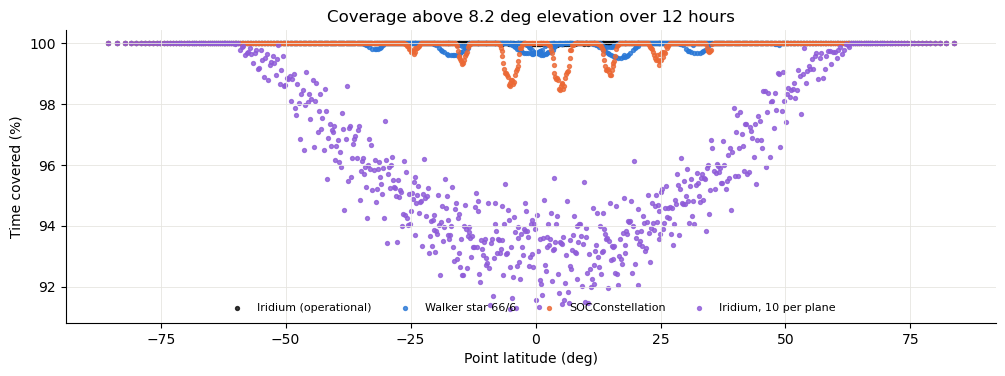

In [4]:
fig, ax = plt.subplots(figsize=(12, 3.8))
for (label, frame), color in zip(results.items(), [INK, BLUE, ORANGE, PURPLE]):
    ax.scatter(frame.latitude, frame["covered (%)"], s=8, color=color, label=label, alpha=0.8)
ax.set(xlabel="Point latitude (deg)", ylabel="Time covered (%)", title=f"Coverage above {MIN_ELEVATION} deg elevation over 12 hours")
ax.legend(frameon=False, fontsize=8, loc="lower center", ncol=4)
plt.show()

TAT-C's coverage analysis reproduces the operational constellation's coverage: the 67 operational Iridium satellites cover 96% of the points continuously over the 12 hours and every point at least 99.95% of the time, with gaps of at most 15 s, matching the coverage sampled independently from the satellites' elevation angles (mean 100.0%, minimum 99.95%). The short gaps occur where the footprints barely overlap, at the 8.2 deg elevation limit.

The generated constellations provide less continuous coverage. A Walker star 66/6 constellation, with planes 30 deg apart and a 30 deg seam, leaves gaps of up to 1.9 minutes near the seam at low latitudes (79% of points continuously covered): its seam is wider than the 23 deg that streets of coverage allow, which Iridium achieves by spacing its co-rotating planes 31.6 deg apart. The `SOCConstellation`, despite having 50% more satellites (99), leaves gaps of up to 1.2 minutes between its touching footprints (78% of points continuously covered). As theory predicts, Iridium's planes with only ten satellites each leave gaps of up to 9 minutes at low latitudes.

## Summary

| Test | Result |
| --- | --- |
| 1. Design (`SOCConstellation`) | polar streets-of-coverage theory reproduces Iridium's 6 planes of 11 satellites; `SOCConstellation` gives 11 planes of 9 (99 satellites) over 360 deg, with touching rather than overlapping footprints |
| 2. Coverage (`collect_multi_observations`, `aggregate_observations`) | operational Iridium: continuous coverage (gaps of at most 15 s) matching an independent computation; Walker star 66/6 and `SOCConstellation`: gaps of up to 1.9 and 1.2 minutes |

**Coverage analysis.** TAT-C's observations and their aggregation reproduce the continuous coverage of the Iridium constellation, as computed independently from the satellites' elevation angles.

**Streets-of-coverage design.** `SOCConstellation` does not reproduce Iridium's design for near-polar orbits: it uses 50% more satellites and still leaves gaps, because its footprints only touch along each plane at a packing distance of 1 and its planes span 360 deg instead of 180 deg. A polar streets-of-coverage option (planes over 180 deg, with the co-rotating and seam spacings of Adams and Rider) and in-plane spacing that overlaps the footprints would reproduce Iridium; TAT-C's Walker star configuration, with equally spaced planes, also needs a narrower seam for continuous coverage.